### TRAIN YOUR VERY FIRST PYTORCH MODEL

Nesse notebook vamos criar um classificador de imagens para identificar cartas jogadas.

Nós vamos abordar esse problema em 3 partes:

    1. Pytorch Dataset
    2. Pytorch Model
    3. Pytorch Training Loop

Quase toda pipeline de modelo de treinamento do pytorch utiliza esse paradigma.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
from tqdm.notebook import tqdm

print('System Version:', sys.version)
print('PyTorch version', torch.__version__)
print('Torchvision version', torchvision.__version__)
print('Numpy version', np.__version__)
print('Pandas version', pd.__version__)

System Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch version 2.10.0+cpu
Torchvision version 0.25.0+cpu
Numpy version 2.0.2
Pandas version 2.2.2


### PASSO 1. PYTORCH DATASET (E DATALOADER)

Você aprenderia como assar um bolo sem antes ter os ingredientes? Não.

A mesma coisa pode ser dita sobre treinar um modelo pytorch sem primeiro ter o dataset configurado corretamente.

Os datasets são importantes pois:


*   É uma forma organizada de estruturar como os dados são carregados para o modelo.
*   Nós podemos então envolver o dataset em um dataloader e o pytorch se encarregará de organizar os dados para treinamento do modelo.



In [ ]:
class PlayingCardDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data = ImageFolder(data_dir, transform=transform)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

    @property
    def classes(self):
        return self.data.classes

### CRIANDO O DATASET DE TESTE

In [ ]:
from google.colab import files

#1. abre a opção de fazer upload do arquivo kaggle.json

print("Faça upload do arquivo kaggle.json")
files.upload()

#2. cria a pasta oculta do kaggle no sistema do colab
!mkdir -p ~/.kaggle

#3. move o arquivo kaggle.json para a pasta oculta do kaggle
!cp kaggle.json ~/.kaggle/

#4. altera as permissões para somente o dono possa ler a chave
!chmod 600 ~/.kaggle/kaggle.json



Faça upload do arquivo kaggle.json


Saving kaggle.json to kaggle.json


In [ ]:

!kaggle datasets download -d gpiosenka/cards-image-datasetclassification --unzip

Dataset URL: https://www.kaggle.com/datasets/gpiosenka/cards-image-datasetclassification
License(s): CC0-1.0
100% 385M/385M [00:01<00:00, 288MB/s]



In [ ]:
import os

print(os.listdir('/content'))

['.config', 'cards.csv', 'valid', 'train', 'test', 'kaggle.json', '53cards-53-(200 X 200)-100.00.h5', '14card types-14-(200 X 200)-94.61.h5', 'sample_data']


In [ ]:
caminho_train = '/content/train'

dataset = PlayingCardDataset(data_dir=caminho_train)

print(f"Total de cartas carregadas no dataset: {len(dataset)}")

Total de cartas carregadas no dataset: 7624


41


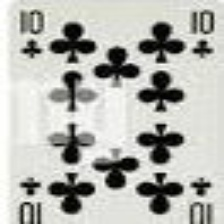

In [ ]:
image, label = dataset[6000]
print(label)
image

In [ ]:
# Get a dictionary associating target values with folder names
data_dir = caminho_train
target_to_class = {v: k for k, v in ImageFolder(data_dir).class_to_idx.items()}
print(target_to_class)

{0: 'ace of clubs', 1: 'ace of diamonds', 2: 'ace of hearts', 3: 'ace of spades', 4: 'eight of clubs', 5: 'eight of diamonds', 6: 'eight of hearts', 7: 'eight of spades', 8: 'five of clubs', 9: 'five of diamonds', 10: 'five of hearts', 11: 'five of spades', 12: 'four of clubs', 13: 'four of diamonds', 14: 'four of hearts', 15: 'four of spades', 16: 'jack of clubs', 17: 'jack of diamonds', 18: 'jack of hearts', 19: 'jack of spades', 20: 'joker', 21: 'king of clubs', 22: 'king of diamonds', 23: 'king of hearts', 24: 'king of spades', 25: 'nine of clubs', 26: 'nine of diamonds', 27: 'nine of hearts', 28: 'nine of spades', 29: 'queen of clubs', 30: 'queen of diamonds', 31: 'queen of hearts', 32: 'queen of spades', 33: 'seven of clubs', 34: 'seven of diamonds', 35: 'seven of hearts', 36: 'seven of spades', 37: 'six of clubs', 38: 'six of diamonds', 39: 'six of hearts', 40: 'six of spades', 41: 'ten of clubs', 42: 'ten of diamonds', 43: 'ten of hearts', 44: 'ten of spades', 45: 'three of clu

In [ ]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

dataset = PlayingCardDataset(data_dir, transform)

In [ ]:
image, label = dataset[100]
image.shape

torch.Size([3, 128, 128])

In [ ]:
for image, label in dataset:
    break

### DATALOADERS

Agrupando os datasets é mais rápido treinar o modelo em lotes do que um de cada vez.

In [ ]:
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)


In [ ]:
for images, labels in dataloader:
    break

In [ ]:
images.shape, labels.shape


(torch.Size([32, 3, 128, 128]), torch.Size([32]))

In [ ]:
labels


tensor([40,  9,  8, 15, 51, 44, 41, 46, 21, 10,  0, 21, 14, 32, 52, 34, 12, 48,
        43, 12, 44, 38, 23, 26, 24, 36, 22, 29, 50, 44, 36, 25])

### ETAPA 2 - Modelo Pytorch

Os conjuntos de dados do PyTorch possuem uma forma estruturada de organizar os dados, e os modelos PyTorch seguem um paradigma semelhante.

* Poderíamos criar o modelo do zero, definindo cada camada.

* No entanto, para tarefas como classificação de imagens, muitas arquiteturas de última geração estão prontamente disponíveis e podemos importá-las de pacotes como o TIMM.

* Entender o modelo PyTorch significa compreender o formato dos dados em cada camada, e a principal camada que precisamos modificar para uma determinada tarefa é a última. Aqui, temos 53 alvos, então modificaremos a última camada.

In [ ]:
class SimpleCardClassifer(nn.Module):
    def __init__(self, num_classes=53):
        super(SimpleCardClassifer, self).__init__()
        # Where we define all the parts of the model
        self.base_model = timm.create_model('efficientnet_b0', pretrained=True)
        self.features = nn.Sequential(*list(self.base_model.children())[:-1])

        enet_out_size = 1280
        # Make a classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(enet_out_size, num_classes)
        )

    def forward(self, x):
        # Connect these parts and return the output
        x = self.features(x)
        output = self.classifier(x)
        return output

In [ ]:
model = SimpleCardClassifer(num_classes=53)
print(str(model)[:500])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

SimpleCardClassifer(
  (base_model): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=Fal


In [ ]:
example_out = model(images)
example_out.shape # [batch_size, num_classes]

torch.Size([32, 53])

### ETAPA 3 - O loop de treinamento

Agora que entendemos o paradigma geral dos conjuntos de dados e modelos do PyTorch, precisamos criar o processo de treinamento deste modelo.
Algumas coisas a considerar: Queremos validar nosso modelo em dados com os quais ele não foi treinado, então geralmente dividimos nossos dados em conjuntos de treinamento e validação. Isso é fácil porque podemos simplesmente criar dois conjuntos de dados usando nossa classe existente.

Termos:
* Epoch: Uma execução por todo o conjunto de dados de treinamento.
* Step: Um lote de dados conforme definido em nosso carregador de dados.
Este loop é um com o qual você se familiarizará ao treinar modelos: você carrega os dados para o modelo em lotes, calcula a perda e realiza a retropropagação. Existem pacotes que automatizam isso, mas é bom ter escrito pelo menos uma vez para entender como funciona.

Duas coisas para guardar:
* Otimizador: Adam é o melhor ponto de partida para a maioria das tarefas.
* loss function: O que o modelo irá otimizar


In [ ]:
# Loss function
criterion = nn.CrossEntropyLoss()
# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
criterion(example_out, labels)
print(example_out.shape, labels.shape)

torch.Size([32, 53]) torch.Size([32])


### SETUP DATASETS

In [ ]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

train_folder = '/content/train'
valid_folder = '/content/valid'
test_folder = '/content/test'

train_dataset = PlayingCardDataset(train_folder, transform=transform)
val_dataset = PlayingCardDataset(valid_folder, transform=transform)
test_dataset = PlayingCardDataset(test_folder, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

### Treinamento de Loop simples

In [ ]:
# Simple training loop
num_epochs = 5
train_losses, val_losses = [], []

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = SimpleCardClassifer(num_classes=53)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc='Training loop'):
        # Move inputs and labels to the device
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # Validation phase
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Validation loop'):
            # Move inputs and labels to the device
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Train loss: {train_loss}, Validation loss: {val_loss}")


Training loop:   0%|          | 0/239 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 1/5 - Train loss: 1.5565232870336094, Validation loss: 0.3912390273696971


Training loop:   0%|          | 0/239 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/9 [00:00<?, ?it/s]

...

Validation loop:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 4/5 - Train loss: 0.24928611685821916, Validation loss: 0.18988686035264213


Training loop:   0%|          | 0/239 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 5/5 - Train loss: 0.18597361143651064, Validation loss: 0.10861106306876776


### Visualizando Perdas

Podemos plotar nossa perda de treino e validação durante este treinamento, geralmente fazemos isso ao final de cada epoch. Vemos que nossa precisão no conjunto de dados de validação é x!

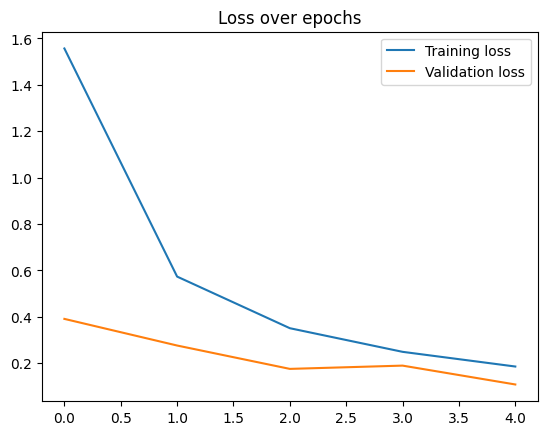

In [ ]:
plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.title("Loss over epochs")
plt.show()

### Avaliando os resultados


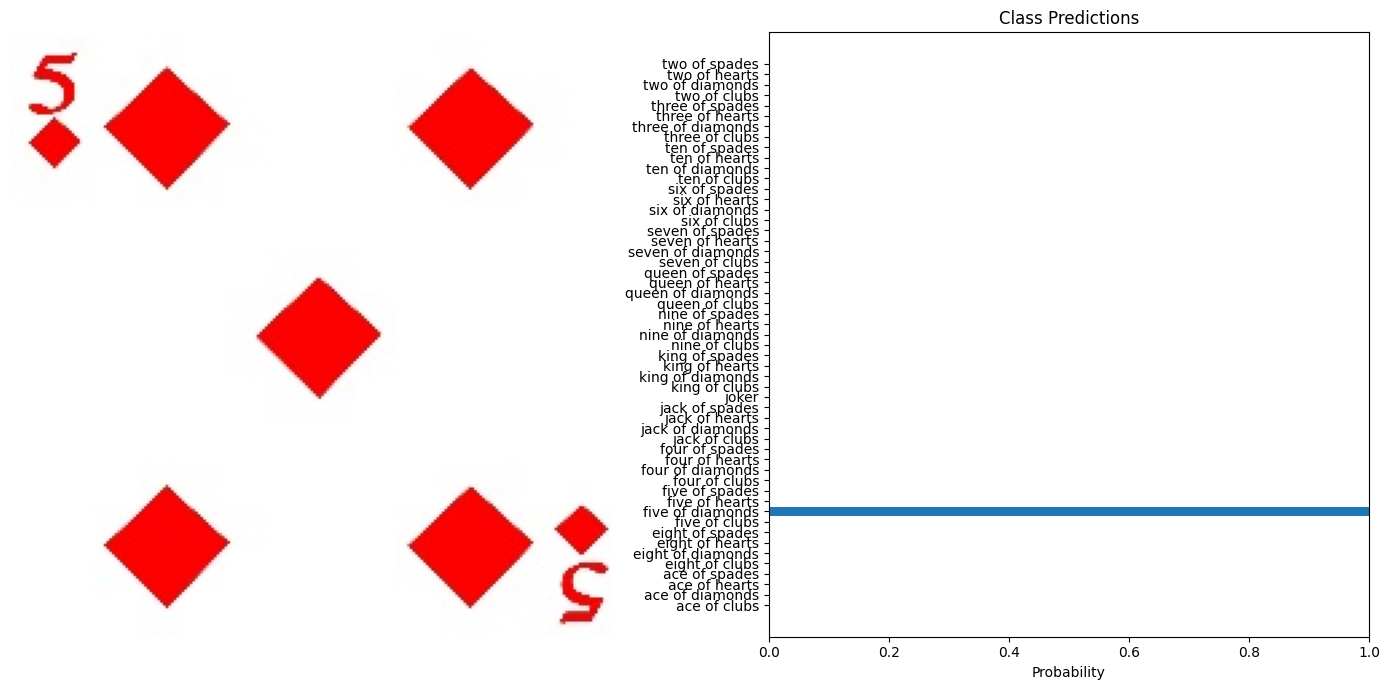

In [25]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load and preprocess the image
def preprocess_image(image_path, transform):
    image = Image.open(image_path).convert("RGB")
    return image, transform(image).unsqueeze(0)

# Predict using the model
def predict(model, image_tensor, device):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
    return probabilities.cpu().numpy().flatten()

# Visualization
def visualize_predictions(original_image, probabilities, class_names):
    fig, axarr = plt.subplots(1, 2, figsize=(14, 7))

    # Display image
    axarr[0].imshow(original_image)
    axarr[0].axis("off")

    # Display predictions
    axarr[1].barh(class_names, probabilities)
    axarr[1].set_xlabel("Probability")
    axarr[1].set_title("Class Predictions")
    axarr[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

# Example usage
test_image = "/content/test/five of diamonds/2.jpg" # Corrected path
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

original_image, image_tensor = preprocess_image(test_image, transform)
probabilities = predict(model, image_tensor, device)

# Assuming dataset.classes gives the class names
class_names = dataset.classes
visualize_predictions(original_image, probabilities, class_names)

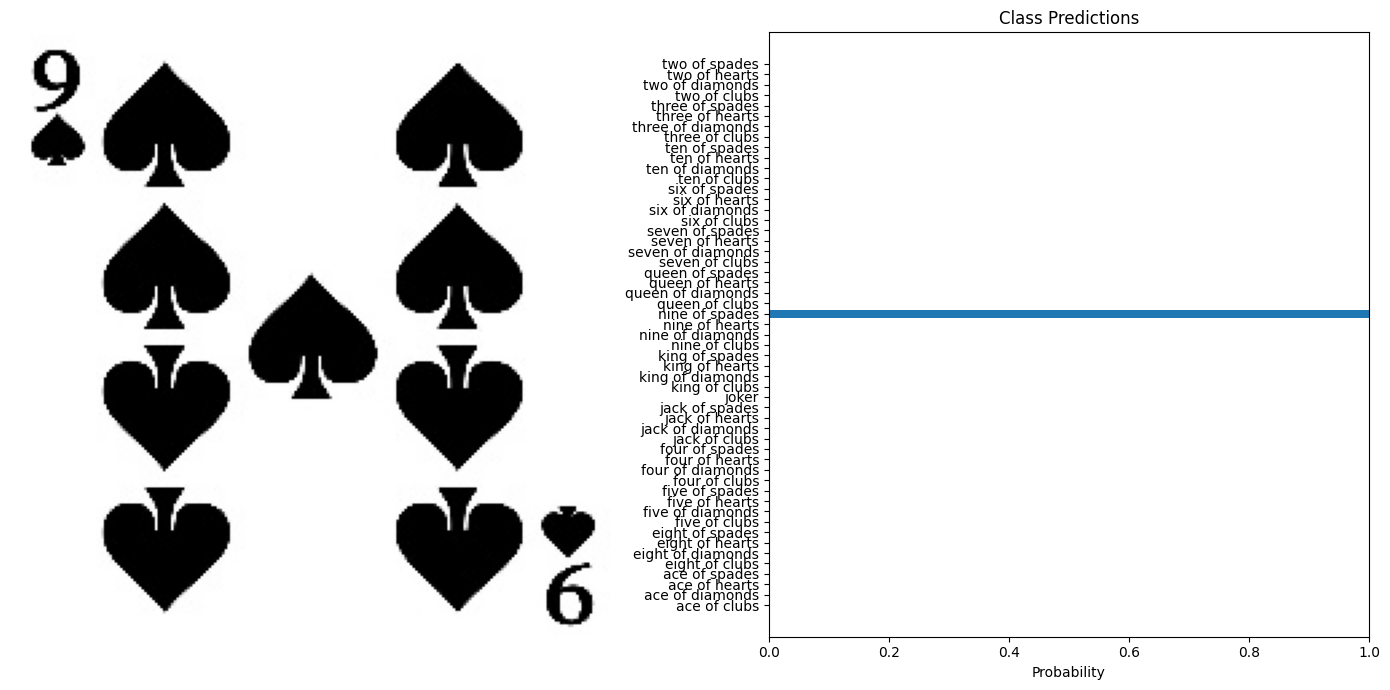

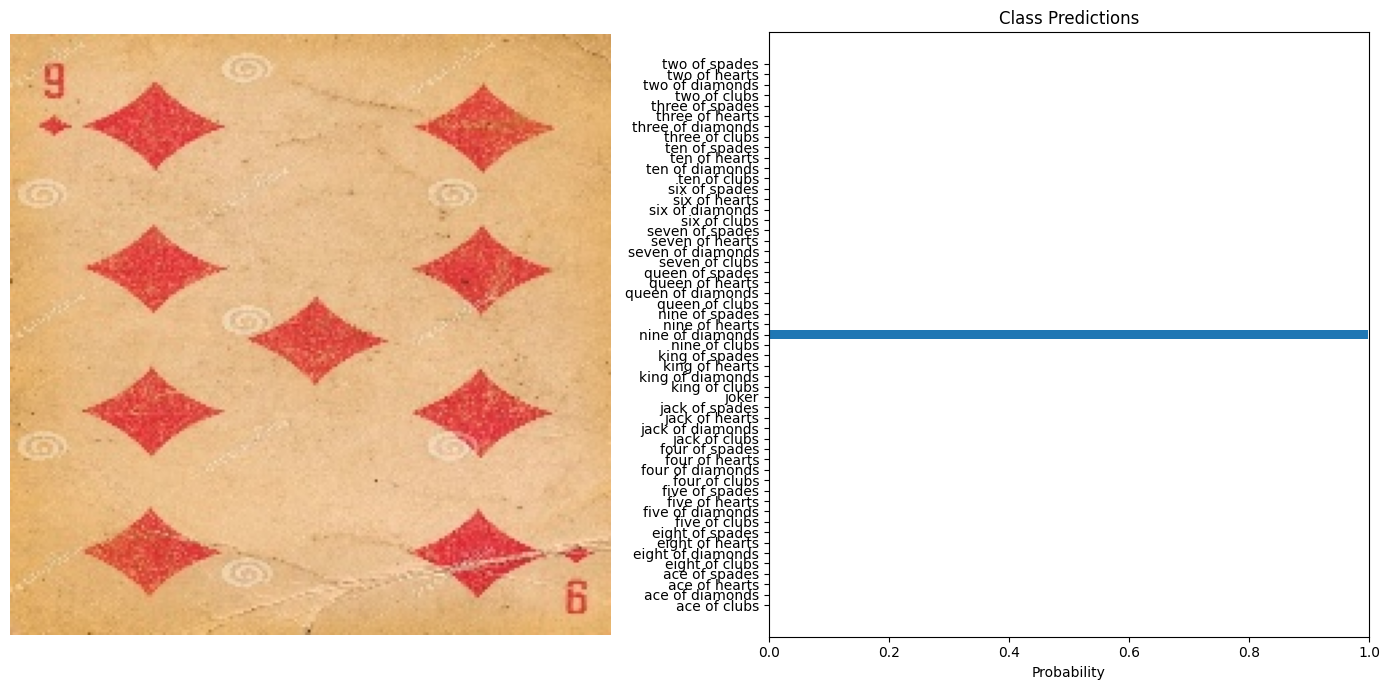

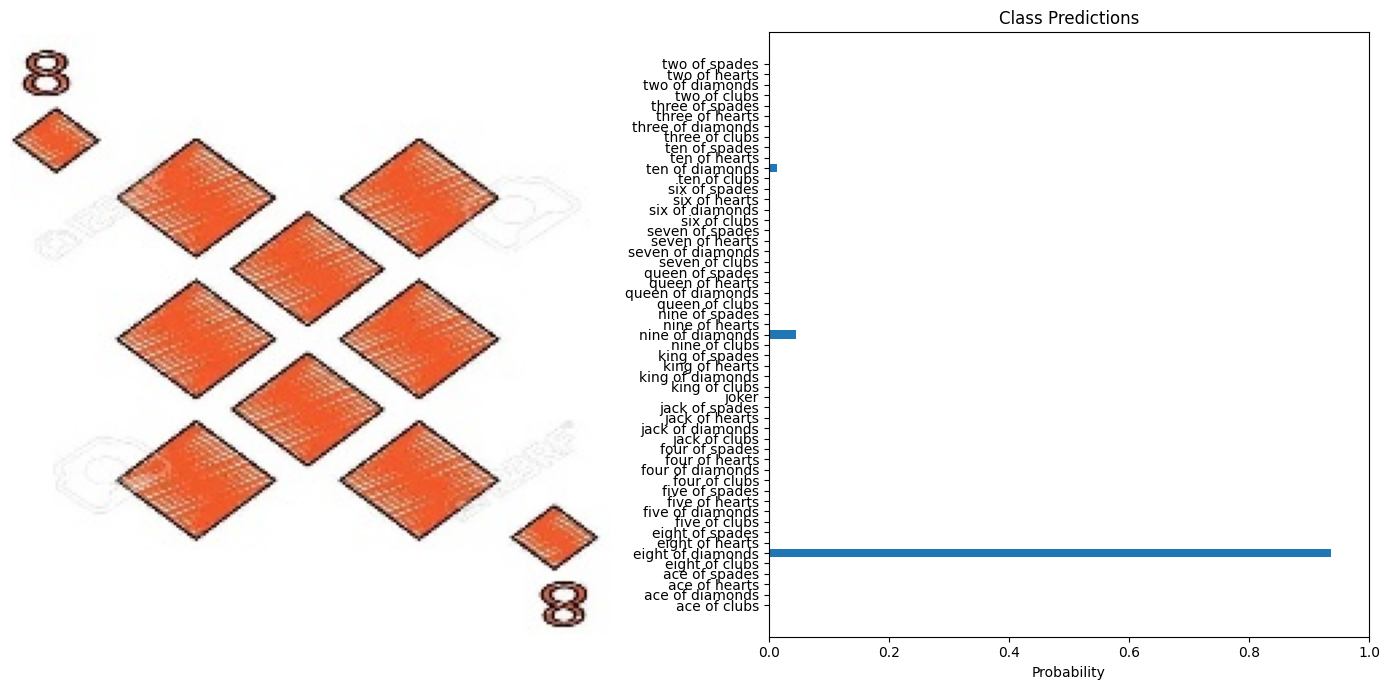

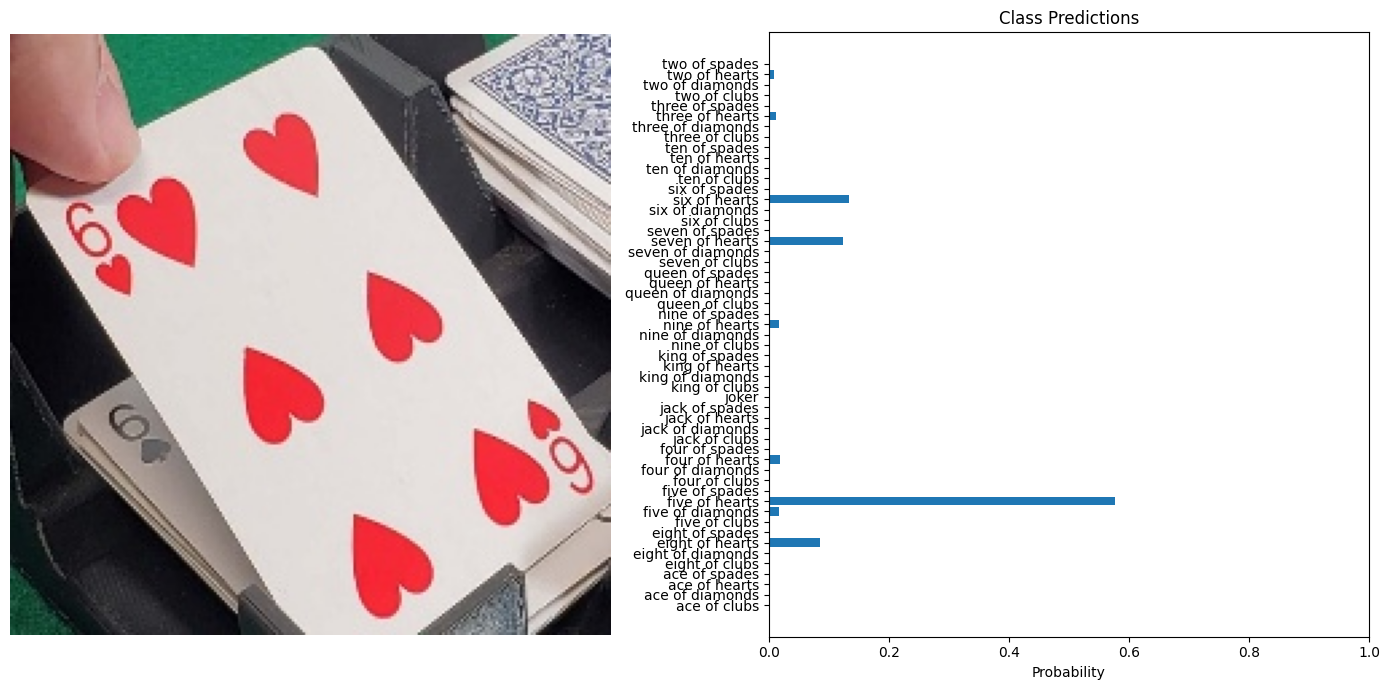

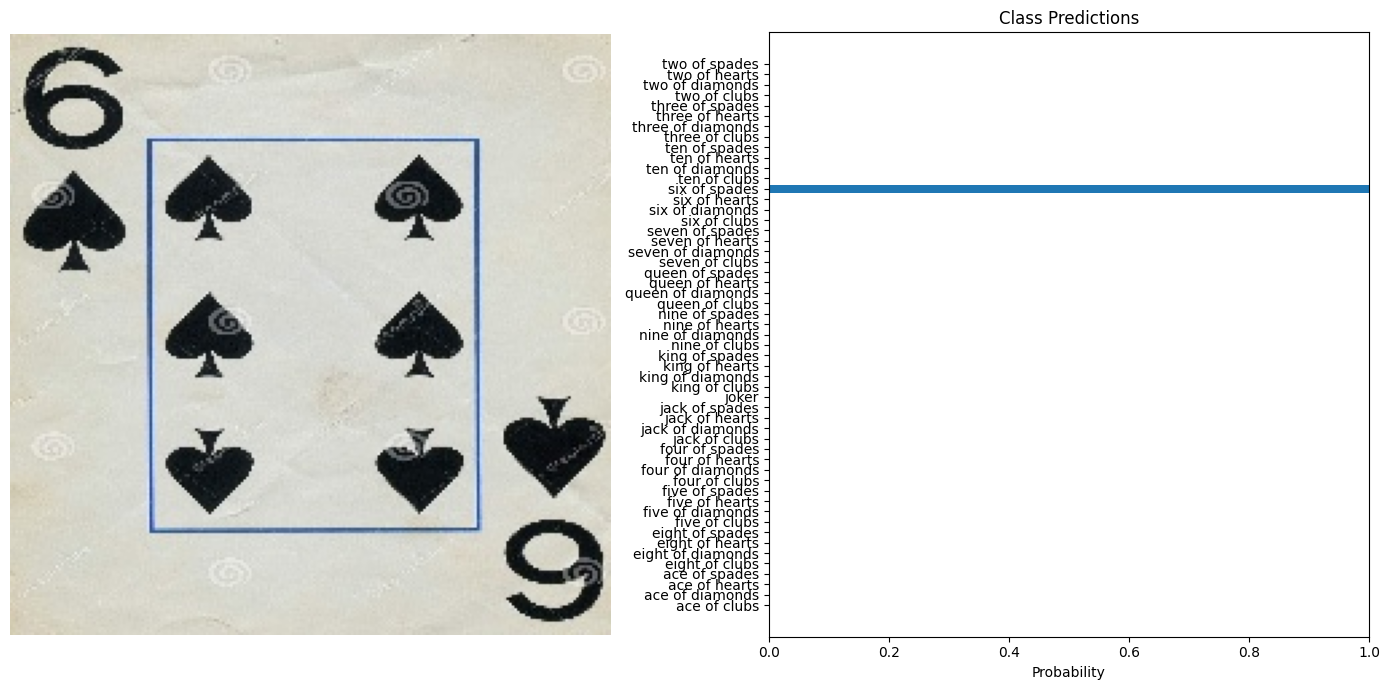

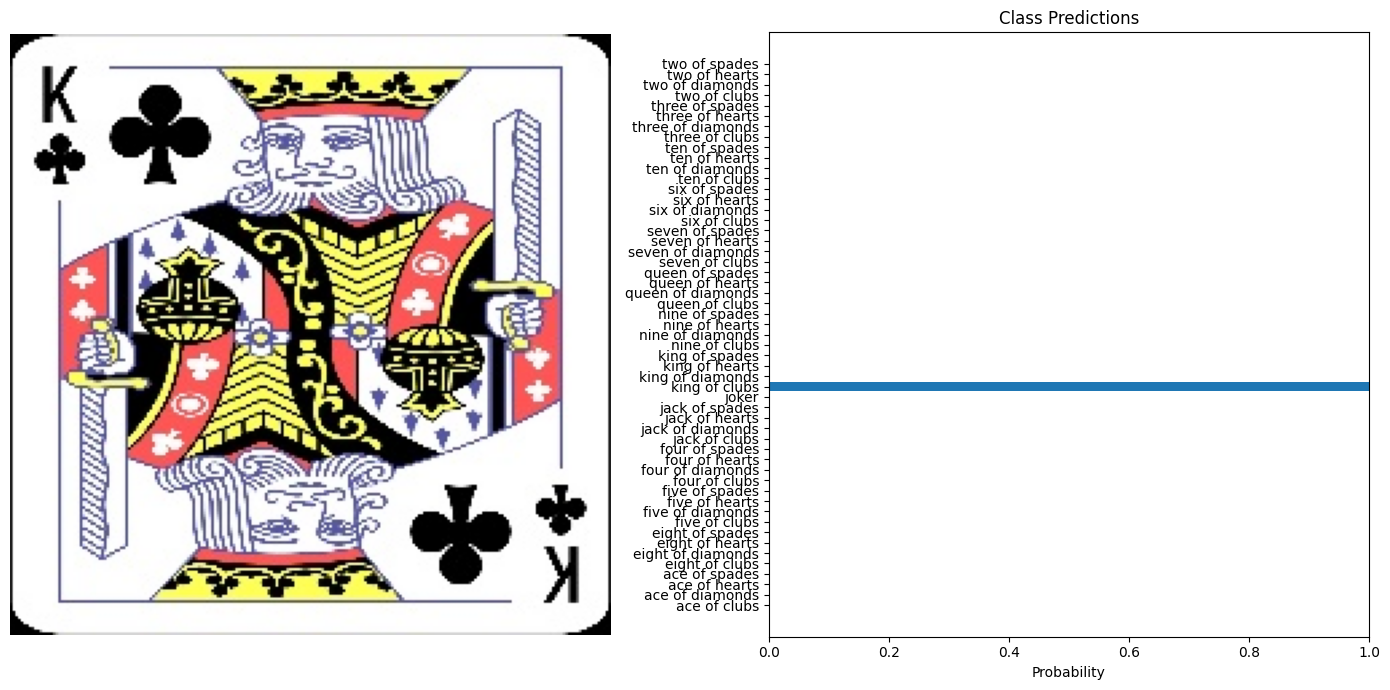

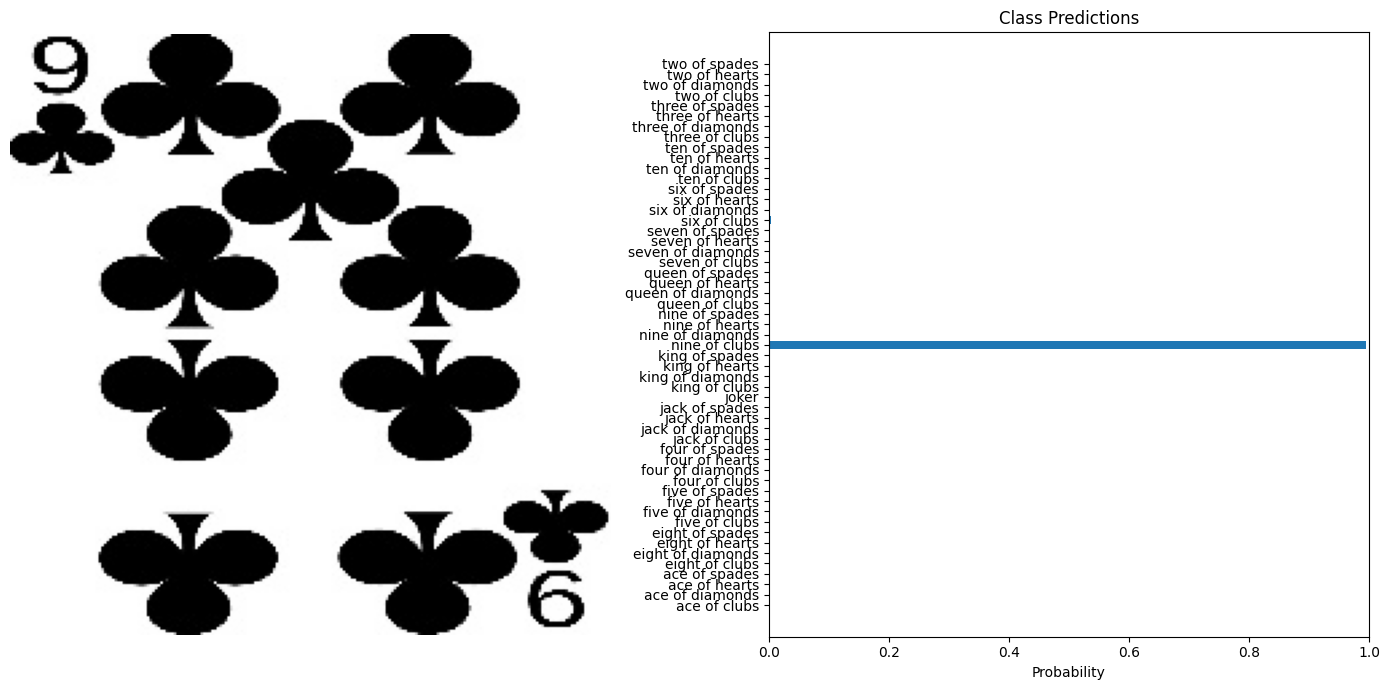

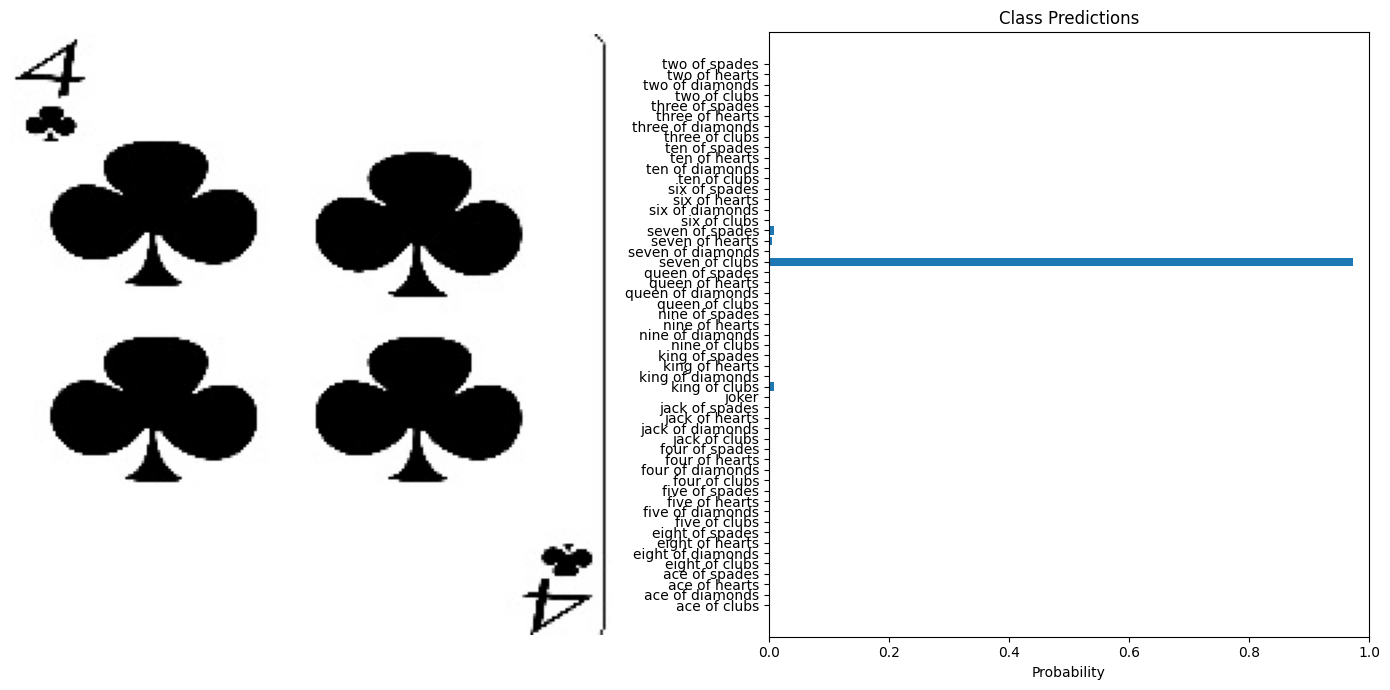

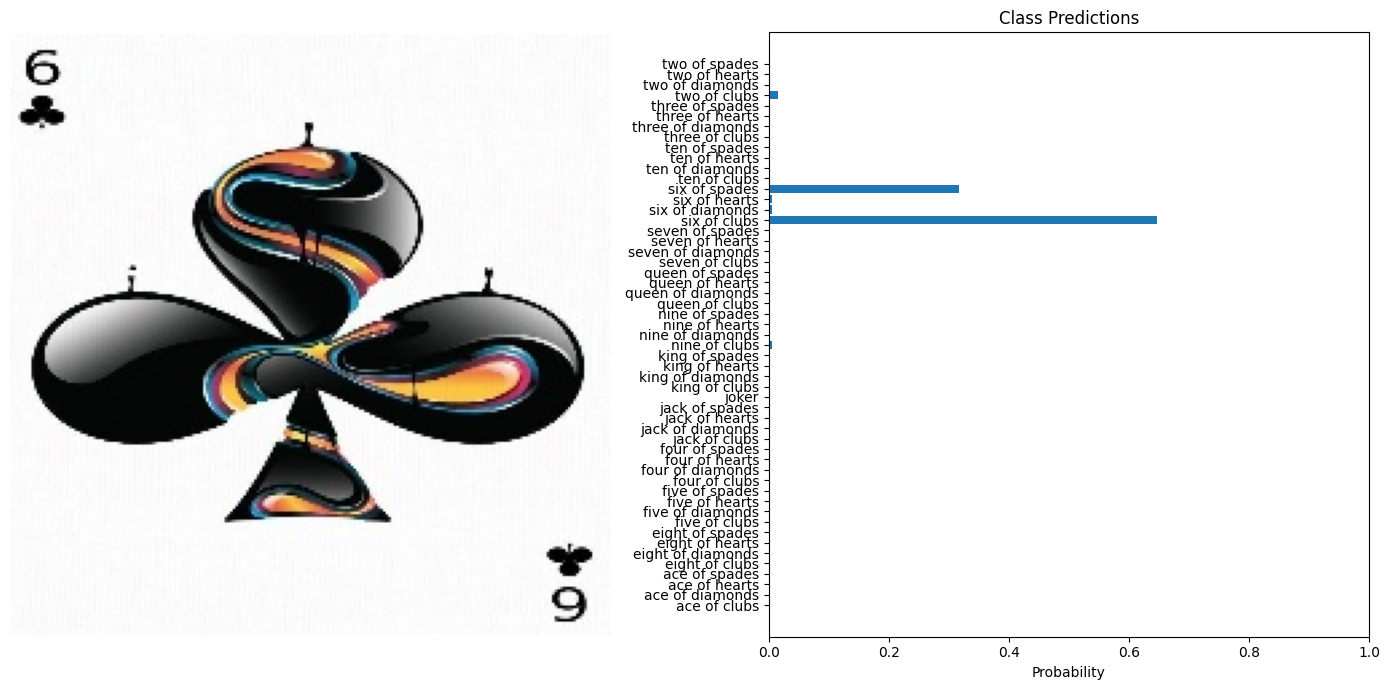

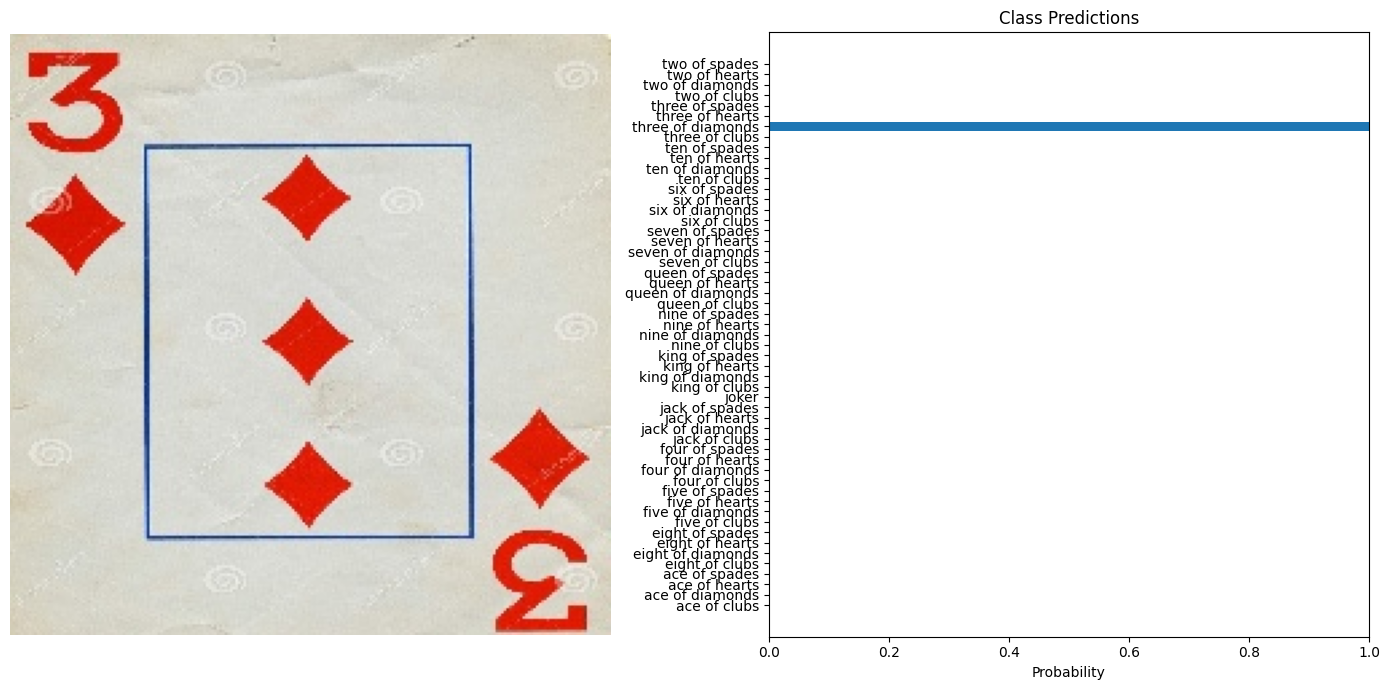

In [26]:
from glob import glob
# Corrected path to find all .jpg files within the test subdirectories
test_images = glob('/content/test/*/*.jpg')
test_examples = np.random.choice(test_images, 10)

for example in test_examples:
    original_image, image_tensor = preprocess_image(example, transform)
    probabilities = predict(model, image_tensor, device)

    # Assuming dataset.classes gives the class names
    class_names = dataset.classes
    visualize_predictions(original_image, probabilities, class_names)